# Alpha and background compensation

Compare raw transparency with apparent-color compensation across backgrounds.

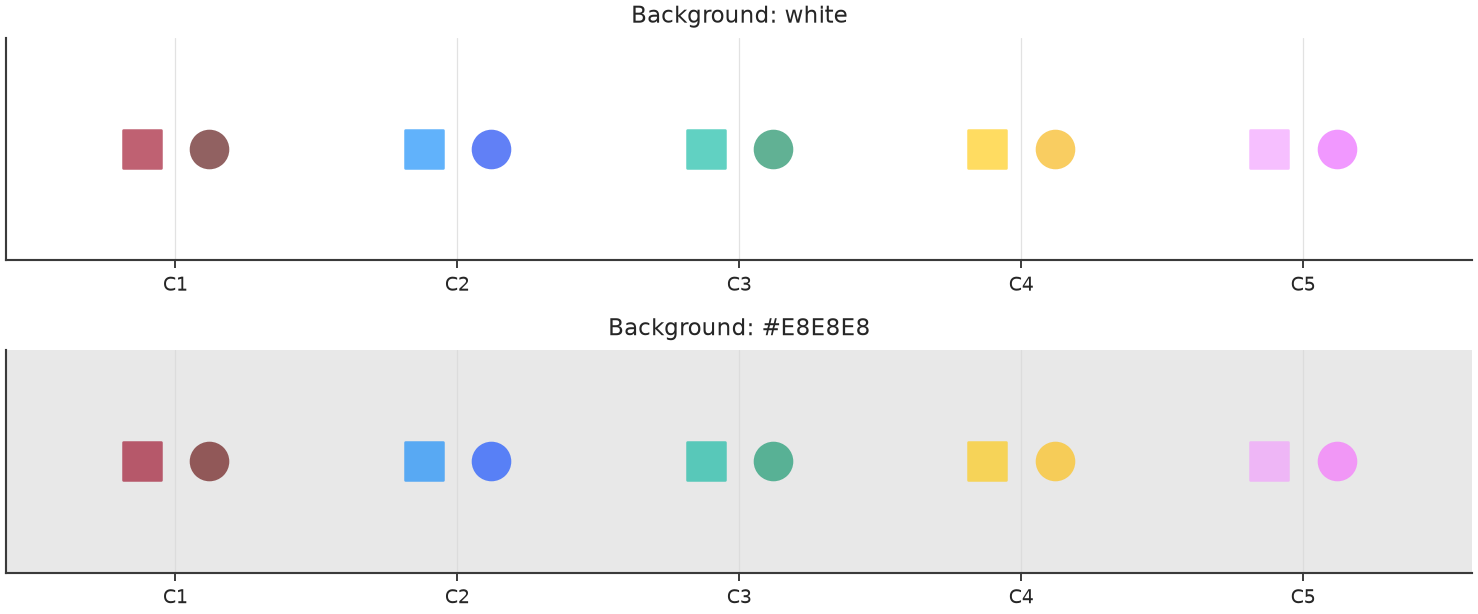

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contrastcolors as cc

cc.set_style("heri", font="DejaVu Sans")
targets=["#97001c","#0083f9","#00b49c","#ffc600","#f198ff"]
alpha=0.62
fig,axes=plt.subplots(2,1,figsize=(8.4,3.6))
backgrounds=["white","#E8E8E8"]

for ax,bg in zip(axes,backgrounds):
    ax.set_facecolor(bg)
    for i,target in enumerate(targets):
        raw=cc.composite(target,bg,alpha)
        fixed=cc.compensate_alpha(target,alpha=alpha,background=bg)
        ax.scatter(i-0.12,0,s=220,color=(*raw,1),marker="s")
        ax.scatter(i+0.12,0,s=220,color=(*fixed.displayed_rgb,1),marker="o")
    ax.set_xlim(-0.6,len(targets)-0.4); ax.set_ylim(-0.5,0.5)
    ax.set_xticks(range(len(targets)),[f"C{i+1}" for i in range(len(targets))])
    ax.set_yticks([]); ax.set_title(f"Background: {bg}")
fig.tight_layout()

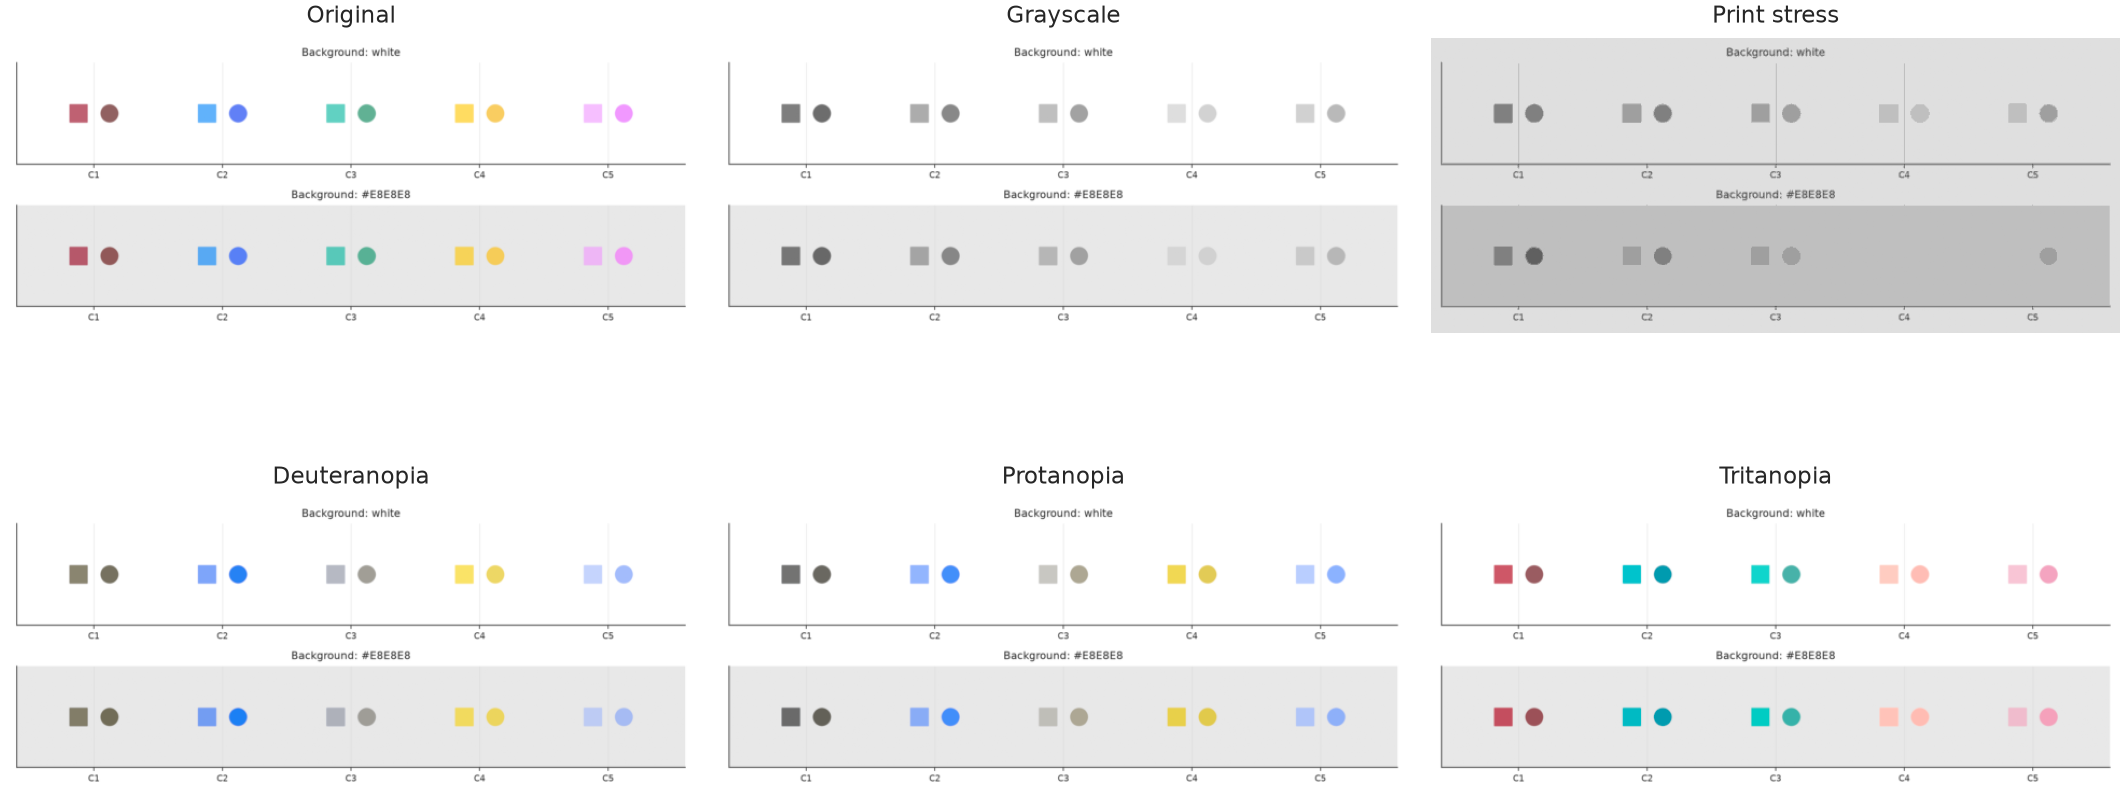

In [2]:
cc.show_accessibility_panel(fig, max_width=640)
plt.show()

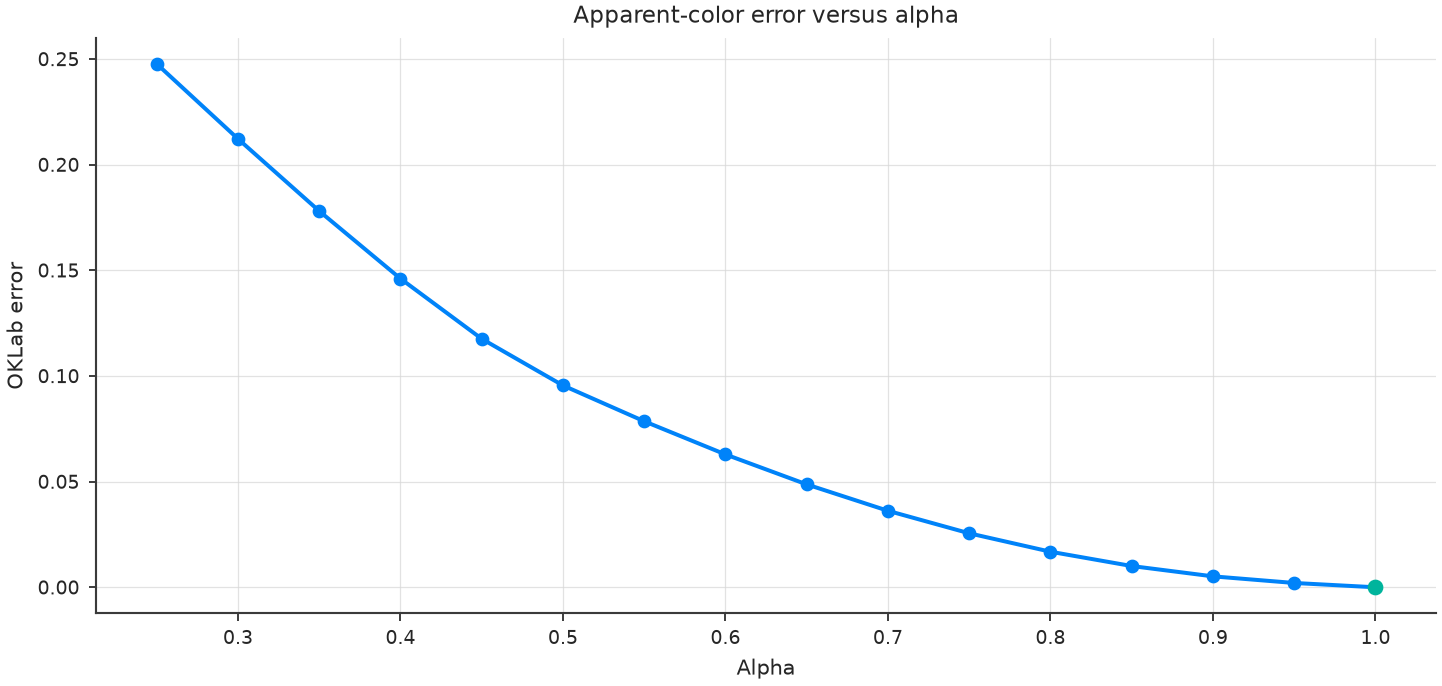

In [3]:
target="#0083f9"
alphas=np.linspace(0.25,1.0,16)
errors=[]; feasible=[]
for a in alphas:
    result=cc.compensate_alpha(target,alpha=float(a),background="white")
    errors.append(result.delta_e_ok); feasible.append(result.feasible)

fig,ax=plt.subplots(figsize=(8.2,4.0))
ax.plot(alphas,errors,color=cc.HERI_PALETTE[1],marker="o")
for a,err,ok in zip(alphas,errors,feasible):
    if ok:
        ax.scatter(a,err,color=cc.HERI_PALETTE[2],s=28,zorder=3)
ax.set(title="Apparent-color error versus alpha",xlabel="Alpha",ylabel="OKLab error")
fig.tight_layout()

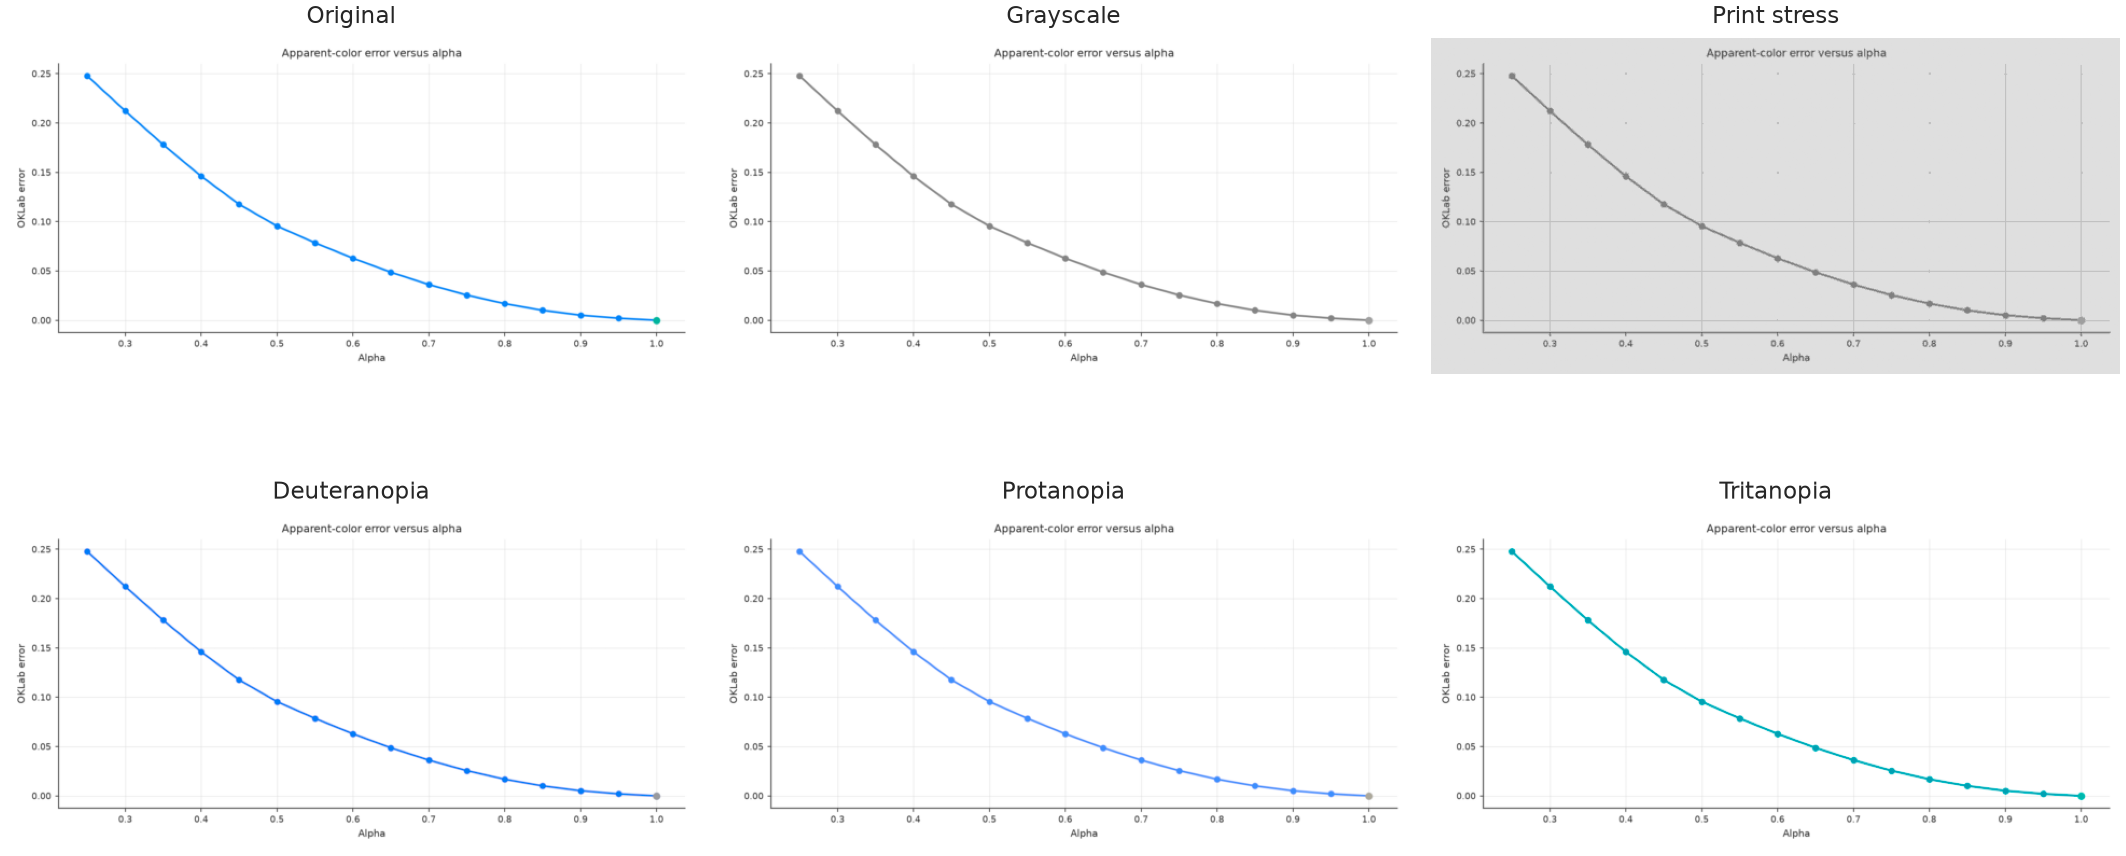

In [4]:
cc.show_accessibility_panel(fig, max_width=640)
plt.show()